#Project mnistDigit

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping


###Definition

In [ ]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


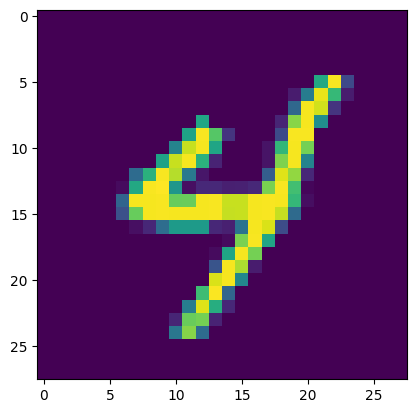

In [ ]:
plt.imshow(X_train[115])


###Normalization

In [ ]:
X_train,X_test=X_train/255,X_test/255

#  چرا توی نرمال سازی فقط ضریب های x را نرمال میکنیم ؟
# X_train,X_test=X_train/255,x_test/255
# چون در MNIST:
# X → ویژگی‌ها (features) یعنی خود پیکسل‌های تصویر هستند (عدد شدت روشنایی 0 تا 255)
# y → برچسب (label) یعنی عدد 0 تا 9 است


###Model

In [ ]:
len(np.unique(y_train))
# مشاهده تعداد خروجی در مدل طبقه بندی و قرار دادن ان در تعداد نورون خروجی در لایه اخر

10

In [ ]:
model = keras.models.Sequential(
    [
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(128,activation="relu"),
    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(10,activation="softmax"),
    ]
 )

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
weight,bias= model.layers[2].get_weights()
print(weight.shape)
print(bias.shape)

(128, 64)
(64,)


###compile

In [ ]:
model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
        )

###EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

###fit

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]

)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9211 - loss: 0.2673 - val_accuracy: 0.9588 - val_loss: 0.1389
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9660 - loss: 0.1136 - val_accuracy: 0.9623 - val_loss: 0.1247
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0774 - val_accuracy: 0.9699 - val_loss: 0.0929
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9750 - val_loss: 0.0888
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9847 - loss: 0.0449 - val_accuracy: 0.9748 - val_loss: 0.0882
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9876 - loss: 0.0369 - val_accuracy: 0.9744 - val_loss: 0.0980
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9911 - loss: 0.0280 - val_accuracy: 0.9740 - val_loss: 0.0991
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9921 - loss: 0.0247 - 

###trainingPerformance

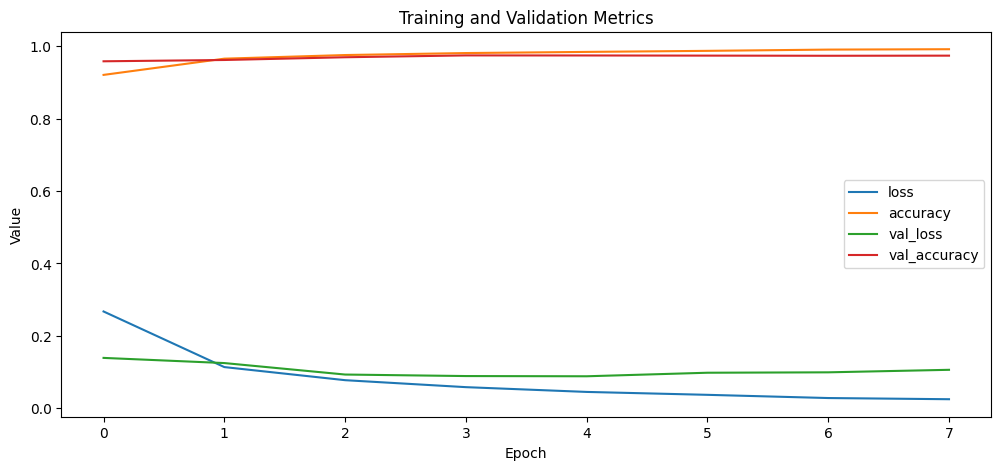

In [ ]:

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(history.history['loss'], label='loss')
ax.plot(history.history['accuracy'], label='accuracy')
ax.plot(history.history['val_loss'], label='val_loss')
ax.plot(history.history['val_accuracy'], label='val_accuracy')

ax.set_xlabel('Epoch')
ax.set_ylabel('Value')
ax.set_title('Training and Validation Metrics')
ax.legend()
plt.show()

### testModel

In [ ]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9725 - loss: 0.0895


[0.0895085409283638, 0.9725000262260437]

In [ ]:
pred = model.predict(X_test[400:450])

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 334ms/step


In [ ]:
np.argmax(pred, axis=1)

array([2, 8, 3, 8, 2, 4, 5, 0, 3, 1, 7, 7, 5, 7, 9, 7, 1, 9, 2, 1, 4, 2,
       9, 2, 0, 4, 9, 1, 4, 8, 1, 8, 4, 5, 9, 8, 8, 3, 7, 6, 0, 0, 3, 0,
       2, 0, 6, 4, 9, 3])

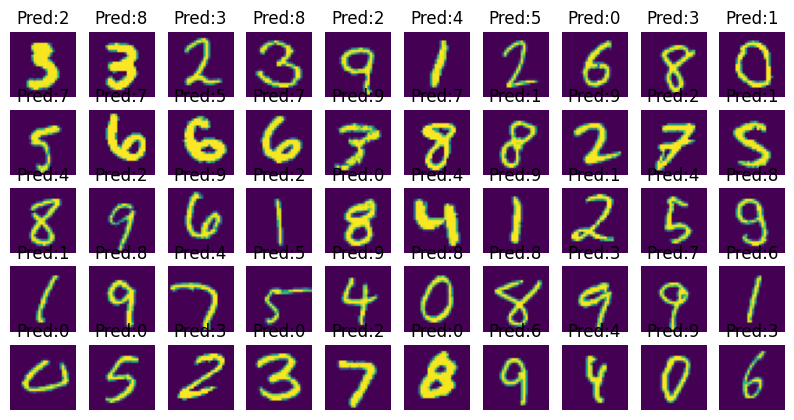

In [ ]:

plt.figure(figsize=(10,10))

for i in range(50):
    plt.subplot(10,10,i+1)
    plt.imshow(X_test[400+i])
    plt.title(f"Pred:{np.argmax(pred[i])}")
    plt.axis("off")

plt.show()